In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.current_device())
gpu = torch.device('cuda:0')

True
0


In [2]:
import numpy as np
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

import torchvision
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor, Pad
from torchvision.io import decode_image
from torchinfo import summary as model_summary

In [3]:
def headless_resnet():
    resnet = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)
    return nn.Sequential(*list(resnet.children())[:-1])

In [4]:
class double_resnet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.resnet1 = headless_resnet()
        self.resnet2 = headless_resnet()

        self.fc1 = nn.Linear(4096, 2048)
        self.fc2 = nn.Linear(2048, 4)

    def forward(self, x):
        x1, x2 = torch.split(x, 3, dim=1)
        
        f1 = self.resnet1(x1)  # (N, 2048, 1, 1)
        f2 = self.resnet2(x2)  # (N, 2048, 1, 1)

        f1 = torch.flatten(f1, 1)  # (N, 2048)
        f2 = torch.flatten(f2, 1)  # (N, 2048)

        f = torch.cat((f1, f2), dim=1)  # (N, 4096)
        f = self.fc1(f) # (N, 2048)
        o = self.fc2(f) # (N, 4)

        return o
        
        

In [3]:
IMG_PATH = "../../dataset/one_revoc/img/"
LABEL_PATH = "../../dataset/one_revoc/label.csv" # (xmin, ymin, xmax, ymax)
ALT_LABEL_PATH = "../../dataset/one_revoc/alt_label.csv" # 
OBJ_PATH = "../../dataset/obj_norm/"

In [8]:
# Subset of VOC'2012 with object removed that CONTAIN ONLY 1 IMAGE
# We stack the tensors for the image and obj together
class CustomDataset(Dataset):
    def __init__(self, label_dir, img_dir, obj_dir, transform=None, target_transform=None, label_names=("img_name","xmin","ymin","xmax","ymax")):
        self.bbox_label = pd.read_csv(label_dir, names=label_names)
        self.img_dir = img_dir
        self.obj_dir = obj_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.bbox_label)

    def __getitem__(self, idx):    
        img_name = self.bbox_label.iloc[idx, 0]
        obj_name = img_name[:-3] + "png"
        img_path = os.path.join(self.img_dir, img_name)
        obj_path = os.path.join(self.obj_dir, obj_name)       
        image = decode_image(img_path).type(torch.float32)
        obj = decode_image(obj_path).type(torch.float32)
        label = torch.tensor([self.bbox_label.iloc[idx, i] for i in range(1,5)]).type(torch.float32)
        if self.transform:
            image = pad_to_500(self.transform(image))
            obj = self.transform(obj)
        if self.target_transform:
            label = self.target_transform(label)
        example = torch.cat((image,obj),0)
        
        return example.to(gpu), label.to(gpu)

    def get_imgname(self, idx):
        return self.bbox_label.iloc[idx, 0]

In [7]:
def get_imgname(revoc, img):
    for idx in range(len(revoc)):
        ds_img, _ = revoc[idx]
        if torch.equal(img, ds_img):
            return revoc.get_imgname(idx)

In [6]:
def pad_to_500(img):
    down = 500 - img.shape[1]
    right = 500 - img.shape[2]
    pad = Pad((0,0,right,down))
    return pad(img)

In [5]:
resnet_preprocess = torchvision.transforms.Compose([
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [10]:
torch.cuda.empty_cache()

In [10]:
batch_size = 16

revoc = CustomDataset(label_dir=LABEL_PATH,
                      img_dir=IMG_PATH,
                      obj_dir=OBJ_PATH,
                      transform=resnet_preprocess)
train_dataset, test_dataset = torch.utils.data.random_split(revoc, [0.8, 0.2])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

In [12]:
model = double_resnet()

In [13]:
model.to(gpu)

double_resnet(
  (resnet1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

In [14]:
def train_loop(dataloader, model, loss_fn, optimizer, t=None):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    total_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)
        total_loss += loss.item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    if t is not None:
        training_result[t] = {"train": total_loss/len(dataloader)}

In [15]:
def test_loop(dataloader, model, loss_fn, t=None):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    
    print(f"Test Loss: {test_loss}")
    if t is not None:
        training_result[t]["test"] = test_loss

In [16]:
learning_rate = 0.001

training_result = {}

loss_fn = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

epochs = 50
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer,t)
    test_loop(test_dataloader, model, loss_fn,t)
print("Done!")

Epoch 1
-------------------------------
loss: 4727034.500000  [   16/ 1107]
Test Loss: 370717.9904513889
Epoch 2
-------------------------------
loss: 226184.906250  [   16/ 1107]
Test Loss: 230201.59385850694
Epoch 3
-------------------------------
loss: 122065.328125  [   16/ 1107]
Test Loss: 208030.3515625
Epoch 4
-------------------------------
loss: 98266.000000  [   16/ 1107]
Test Loss: 240354.76106770834
Epoch 5
-------------------------------
loss: 92910.593750  [   16/ 1107]
Test Loss: 192585.41427951388
Epoch 6
-------------------------------
loss: 65974.460938  [   16/ 1107]
Test Loss: 221358.46864149306
Epoch 7
-------------------------------
loss: 73646.796875  [   16/ 1107]
Test Loss: 230267.7265625
Epoch 8
-------------------------------
loss: 73842.242188  [   16/ 1107]
Test Loss: 226524.75564236112
Epoch 9
-------------------------------
loss: 122122.875000  [   16/ 1107]
Test Loss: 280091.5520833333
Epoch 10
-------------------------------
loss: 95179.109375  [   16/ 

In [17]:
x = list(training_result.keys())

In [19]:
y,y2 = [], []
for i in range(50):
    y.append(training_result[i]["train"])
    y2.append(training_result[i]["test"])

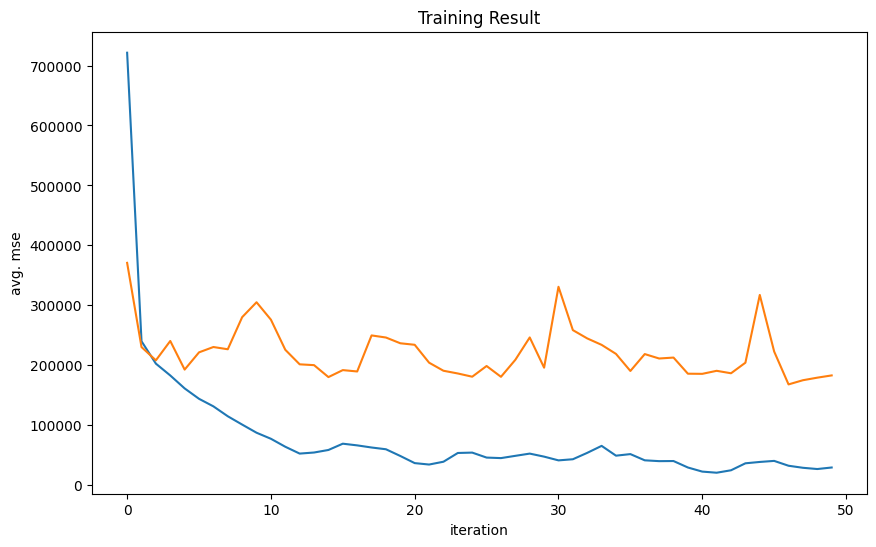

In [20]:
fig= plt.figure(figsize=(10,6))
plt.title("Training Result")
plt.xlabel("iteration")
plt.ylabel("avg. mse")
plt.plot(x,y)
plt.plot(x,y2)
plt.show()

In [21]:
torch.save(model.state_dict(), "weights.pt")

In [22]:
import json
with open("trainingresult.json", "w") as f:
    json.dump(training_result, f)

In [23]:
def save_eval(dataset, model, loss_fn, out_dir="output/"):
    # Do prediction one by one so we can save result
    model.eval()
    total_loss = 0

    with open(os.path.join(out_dir, "output.csv"), "a") as out_file:
    
        # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
        # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
        with torch.no_grad():
            for X, y in dataset:
                pred = model(X)
                out_name = []
                out_label = []
                out_pred = []
                for x in X:
                    name = get_imgname(revoc, x)
                    # name = "placeholder"
                    out_name.append(name)
                for label in y:
                    xmin, ymin, xmax, ymax = [str(int(x)) for x in label.tolist()]
                    out_label.append(",".join([xmin, ymin, xmax, ymax]))
                for label in pred:
                    pred_xmin, pred_ymin, pred_xmax, pred_ymax = [str(int(x)) for x in label.tolist()]
                    out_pred.append(",".join([pred_xmin, pred_ymin, pred_xmax, pred_ymax]))
                for i in range(len(out_name)):
                    out_file.write(out_name[i] + "," + out_label[i] + "," + out_pred[i] + "\n")
        
        

In [24]:
save_eval(test_dataloader, model, loss_fn)